# 내 프로젝트 v1

# 실습 16 - 문제 정의서

## Step 0. 데이터 확인하기

In [1]:
import pandas as pd

df = pd.read_csv('../../data/day06_semiconductor_yield.csv')

# 1. 전체 행 수와 열 수
print(df.shape[0], '행,', df.shape[1], '열')

# 2. 숫자형 열 개수
numeric_cols = df.select_dtypes(include='number').columns
print(len(numeric_cols), '개 숫자형 열')

# 3. 전체 열을 자료형별로 구분해서 종류와 개수 확인
print(df.dtypes.value_counts())


1250 행, 28 열
19 개 숫자형 열
float64    18
str         9
int64       1
Name: count, dtype: int64


**자료형 범례**: <code style="color:#2563eb">s = 문자형</code> · <code style="color:#d97706">i = 정수형</code> · <code style="color:#16a34a">f = 실수형</code>

| 구분 | 열 | 특징 |
|---|---|---|
| 제품/공정 | <code style="color:#2563eb">product_type(s)</code>, <code style="color:#2563eb">technology_node(s)</code> | - 제품/노드별 공정 난이도 차이 존재<br>- 수율 목표도 다를듯  |
| 이력/그룹 | <code style="color:#2563eb">lot_id(s)</code>, <code style="color:#2563eb">process_date(s)</code>, <code style="color:#2563eb">wafer_id(s)</code> | - 식별 코드<br> - 그룹/시계열 분석에 활용 시 적합할듯 |
| 장비명 | <code style="color:#2563eb">etch_tool(s)</code>, <code style="color:#2563eb">litho_tool(s)</code>, <code style="color:#2563eb">deposition_tool(s)</code>, <code style="color:#2563eb">implant_tool(s)</code> | - 특정 장비의 수율 저하 여부 확인 가능<br>- 장비 조합 별 수율 저하가 있는지도 확인 필요(LOT별 장비 조합은 동일) |
| 공정 조건 | <code style="color:#16a34a">etch_rate(f)</code>, <code style="color:#16a34a">pressure(f)</code>, <code style="color:#16a34a">temperature(f)</code>, <code style="color:#16a34a">exposure_time(f)</code>, <code style="color:#16a34a">focus_offset(f)</code>, <code style="color:#16a34a">dose(f)</code>, <code style="color:#16a34a">deposition_rate(f)</code>, <code style="color:#16a34a">thickness_uniformity(f)</code>, <code style="color:#16a34a">implant_energy(f)</code>, <code style="color:#16a34a">tilt_angle(f)</code> | 액션으로 연결 가능한 원인 후보 |
| 계측값 | <code style="color:#16a34a">critical_dimension(f)</code>, <code style="color:#16a34a">oxide_thickness(f)</code>, <code style="color:#16a34a">resistivity(f)</code>, <code style="color:#16a34a">vth(f)</code>, <code style="color:#16a34a">leakage_current(f)</code>, <code style="color:#16a34a">resistance(f)</code> | 수율 저하와 연결된 품질 특성 확인 |
| 결함 | <code style="color:#d97706">defect_count(i)</code>, <code style="color:#16a34a">defect_density(f)</code> | 저수율의 직접적 설명 요인 후보 |


### 제품군별 technology_node · 장비 조합

<table>
<tr><th>제품군</th><th>장비 조합 (etch / litho / deposition / implant)</th><th>technology_node</th><th>표본 수</th></tr>
<tr><td rowspan="7">ASIC</td><td>ETCH_01 · LITHO_01 · DEP_03 · IMP_02</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_03 · LITHO_02 · DEP_01 · IMP_03</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_04 · LITHO_03 · DEP_01 · IMP_02</td><td>14nm</td><td>25</td></tr>
<tr><td>ETCH_04 · LITHO_04 · DEP_01 · IMP_01</td><td>14nm</td><td>50</td></tr>
<tr><td>ETCH_05 · LITHO_04 · DEP_03 · IMP_02</td><td>22nm</td><td>25</td></tr>
<tr><td>ETCH_01 · LITHO_04 · DEP_01 · IMP_03</td><td>28nm</td><td>25</td></tr>
<tr><td>ETCH_05 · LITHO_03 · DEP_02 · IMP_01</td><td>28nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td rowspan="10">CPU</td><td>ETCH_04 · LITHO_03 · DEP_01 · IMP_01</td><td>7nm, 14nm</td><td>50</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_05 · LITHO_04 · DEP_03 · IMP_03</td><td>7nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_01 · LITHO_01 · DEP_02 · IMP_01</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_02 · LITHO_01 · DEP_03 · IMP_01</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_02 · LITHO_04 · DEP_03 · IMP_01</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_03 · LITHO_01 · DEP_01 · IMP_01</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_04 · LITHO_01 · DEP_02 · IMP_02</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_04 · LITHO_03 · DEP_02 · IMP_01</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_03 · LITHO_02 · DEP_01 · IMP_01</td><td>14nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_04 · LITHO_02 · DEP_02 · IMP_01</td><td>14nm</td><td>25</td></tr>
<tr><td rowspan="11">FPGA</td><td>ETCH_01 · LITHO_01 · DEP_01 · IMP_01</td><td>7nm</td><td>25</td></tr>
<tr><td>ETCH_01 · LITHO_03 · DEP_03 · IMP_02</td><td>7nm</td><td>25</td></tr>
<tr><td>ETCH_01 · LITHO_04 · DEP_01 · IMP_03</td><td>7nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_04 · DEP_01 · IMP_03</td><td>7nm</td><td>25</td></tr>
<tr><td>ETCH_03 · LITHO_04 · DEP_01 · IMP_03</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_04 · DEP_02 · IMP_03</td><td>14nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_02 · DEP_03 · IMP_02</td><td>22nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_04 · DEP_03 · IMP_02</td><td>22nm</td><td>25</td></tr>
<tr><td>ETCH_01 · LITHO_03 · DEP_02 · IMP_01</td><td>28nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_02 · DEP_02 · IMP_01</td><td>28nm</td><td>25</td></tr>
<tr><td>ETCH_03 · LITHO_04 · DEP_03 · IMP_02</td><td>28nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td rowspan="10">GPU</td><td>ETCH_03 · LITHO_01 · DEP_03 · IMP_03</td><td>7nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_05 · LITHO_01 · DEP_01 · IMP_01</td><td>7nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_04 · LITHO_02 · DEP_02 · IMP_03</td><td>10nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_05 · LITHO_04 · DEP_01 · IMP_02</td><td>10nm, 28nm</td><td>50</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_01 · LITHO_01 · DEP_02 · IMP_01</td><td>14nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_04 · LITHO_02 · DEP_01 · IMP_02</td><td>14nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_04 · LITHO_04 · DEP_01 · IMP_02</td><td>22nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_02 · LITHO_01 · DEP_01 · IMP_03</td><td>28nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_02 · LITHO_02 · DEP_02 · IMP_02</td><td>28nm</td><td>25</td></tr>
<tr style="background-color:#eeeeee"><td>ETCH_05 · LITHO_01 · DEP_03 · IMP_01</td><td>28nm</td><td>25</td></tr>
<tr><td rowspan="9">Memory</td><td>ETCH_01 · LITHO_01 · DEP_03 · IMP_02</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_04 · DEP_01 · IMP_01</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_03 · LITHO_01 · DEP_03 · IMP_03</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_03 · LITHO_04 · DEP_01 · IMP_03</td><td>10nm</td><td>25</td></tr>
<tr><td>ETCH_05 · LITHO_03 · DEP_01 · IMP_03</td><td>14nm</td><td>25</td></tr>
<tr><td>ETCH_04 · LITHO_04 · DEP_03 · IMP_01</td><td>22nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_01 · DEP_03 · IMP_02</td><td>28nm</td><td>25</td></tr>
<tr><td>ETCH_02 · LITHO_03 · DEP_01 · IMP_01</td><td>28nm</td><td>25</td></tr>
<tr><td>ETCH_03 · LITHO_02 · DEP_03 · IMP_01</td><td>28nm</td><td>25</td></tr>
</table>

- 각 행이 실제로 존재하는 장비 조합(etch·litho·deposition·implant 4종 세트) 하나이며, 그 조합이 실제로 쓰인 `technology_node`와 그 조합에 해당하는 웨이퍼 표본 수를 옆에 매칭했다. 제품군 안에서는 노드 오름차순(7nm→10nm→14nm→22nm→28nm)으로 정렬했다. `lot_id` 단위로는 이 조합이 항상 1가지로 고정됨 (같은 lot 안 웨이퍼는 모두 같은 조합 사용)
- 대부분(47개 중 45개) 조합은 노드 1개에서만 쓰였고, 2개 조합만 두 노드에 걸쳐 쓰임: CPU의 `ETCH_04·LITHO_03·DEP_01·IMP_01`(7nm, 14nm), GPU의 `ETCH_05·LITHO_04·DEP_01·IMP_02`(10nm, 28nm) — 이 두 행은 더 작은 노드 기준으로 정렬 위치를 잡았다
- 표본 수는 대부분 25(=lot 1개당 웨이퍼 25장)이며, 같은 조합이 lot 2개에서 쓰인 경우만 50이다. 표본 수 합계는 제품군별로 ASIC 200, CPU 275, FPGA 275, GPU 275, Memory 225 (전체 1250과 일치)
- 제품군별 서로 다른 조합 수: ASIC 7종, CPU 10종, FPGA 11종, GPU 10종, Memory 9종


---
## Step 1. 문제 정의

**한 문장** : 반도체 공정 흐름에 대한 공정 파라미터와 계측값으로, 수율이 떨어진 원인을 분석해 수율 하락을 방지하는 대안을 마련한다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 각 단위 공정 기술 엔지니어 |
| 무엇을 결정하나 | 이 웨이퍼를 후속 공정으로 보낼지 말지 |
| 언제 결정하나 | 인라인 데이터 측정 이후 |
| 이 판단이 늦으면 | 불량이 다음 공정/패키징/고객사로 넘어가게 되면, 소요 시간/비용/신뢰도에서 모두 손해를 본다 |

---
## Step 2. 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | Kaggle_Semiconductor Yield data |
| 규모 | 1250행 x 28열 |
| 입력으로 쓸 열 | [숫자로 된 측정 열 8개] |
| 결과 열 | yield |
| 결과 열의 값 | 숫자 |
| 기준선이 될 숫자 | [불합격 133건 (4.67%)] |

### 수율 트렌드 : 제품군 전체 평균 ±3σ 관리도  /  제품군+노드별 표준화 관리도

In [2]:
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SIGMA_K = 2  # LSL 기준: 평균 - K*표준편차 (저수율 관리 목적이라 USL은 보지 않음)


def node_num(n):
    return int(n.replace('nm', ''))


def plot_pooled_chart(ax, pt):
    """제품군 pt의 전체 노드를 하나로 묶어 LSL(평균-Kσ) 관리선을 그린다."""
    node_order = sorted(df.loc[df['product_type'] == pt, 'technology_node'].unique(), key=node_num)
    g = df[df['product_type'] == pt].copy()
    g['technology_node'] = pd.Categorical(g['technology_node'], categories=node_order, ordered=True)
    g = g.sort_values(['technology_node', 'process_date', 'lot_id', 'wafer_id']).reset_index(drop=True)

    m, s = g['yield'].mean(), g['yield'].std()
    lsl = m - SIGMA_K * s
    below = g['yield'] < lsl
    normal = ~below

    ax.plot(g.index, g['yield'], color='lightgray', linewidth=0.6, zorder=1)
    ax.scatter(g.index[normal], g.loc[normal, 'yield'], color='gray', s=12, alpha=0.5,
               label='정상 범위', zorder=2)
    if below.any():
        lots = ', '.join(sorted(g.loc[below, 'lot_id'].unique()))
        ax.scatter(g.index[below], g.loc[below, 'yield'], color='red', s=60,
                   edgecolor='black', linewidth=0.6, label=f'LSL 미만 - 저수율 ({lots})', zorder=4)

    ax.axhline(m, color='black', linewidth=1, label=f'중심선(평균={m:.3f})')
    ax.axhline(lsl, color='green', linewidth=1, linestyle='--', label=f'LSL={lsl:.3f} (평균-{SIGMA_K}σ)')

    for node in node_order:
        idx = g.index[g['technology_node'] == node]
        start, end = idx.min(), idx.max()
        if start > 0:
            ax.axvline(start - 0.5, color='#999999', linewidth=0.8, linestyle=':')
        ax.text((start + end) / 2, 1.01, node, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=8, color='#555555')

    ax.set_title(f'{pt} 수율 관리도 (전체 노드 통합, 저수율 관리 LSL = 평균-{SIGMA_K}σ)', pad=22)
    ax.set_ylabel('yield')
    ax.set_xlabel('측정 순서 (technology_node 오름차순 → process_date → lot_id → wafer_id)')
    ax.legend(loc='lower right', fontsize=7)


def plot_standardized_chart(ax, pt):
    """제품군 pt를 노드별로 표준화(z-score)한 뒤 노드 오름차순으로 이어붙여 LSL(z=-Kσ)만 표기한다.
    반환값: LSL 미만인 이상치의 technology_node, lot_id, wafer_id 표
    """
    node_order = sorted(df.loc[df['product_type'] == pt, 'technology_node'].unique(), key=node_num)
    g = df[df['product_type'] == pt].copy()
    g['technology_node'] = pd.Categorical(g['technology_node'], categories=node_order, ordered=True)
    g = g.sort_values(['technology_node', 'process_date', 'lot_id', 'wafer_id']).reset_index(drop=True)

    node_mean = g.groupby('technology_node', observed=True)['yield'].transform('mean')
    node_std = g.groupby('technology_node', observed=True)['yield'].transform('std')
    g['z'] = (g['yield'] - node_mean) / node_std

    below = g['z'] < -SIGMA_K
    normal = ~below

    ax.plot(g.index, g['z'], color='lightgray', linewidth=0.6, zorder=1)
    ax.scatter(g.index[normal], g.loc[normal, 'z'], color='gray', s=12, alpha=0.5,
               label='정상 범위', zorder=2)
    if below.any():
        lots = ', '.join(sorted(g.loc[below, 'lot_id'].unique()))
        ax.scatter(g.index[below], g.loc[below, 'z'], color='red', s=60,
                   edgecolor='black', linewidth=0.6, label=f'LSL 미만 - 저수율 ({lots})', zorder=4)

    ax.axhline(0, color='black', linewidth=1, label='중심선 (노드별 표준화 평균=0)')
    ax.axhline(-SIGMA_K, color='green', linewidth=1, linestyle='--', label=f'LSL = -{SIGMA_K}σ')

    for node in node_order:
        idx = g.index[g['technology_node'] == node]
        start, end = idx.min(), idx.max()
        if start > 0:
            ax.axvline(start - 0.5, color='#999999', linewidth=0.8, linestyle=':')
        ax.text((start + end) / 2, 1.01, node, transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=8, color='#555555')

    ax.set_title(f'{pt} 수율 관리도 (노드별 표준화 후 오름차순 연결, 저수율 관리 LSL = -{SIGMA_K}σ)', pad=22)
    ax.set_ylabel('표준화 수율 (z-score)')
    ax.set_xlabel('측정 순서 (technology_node 오름차순 → process_date → lot_id → wafer_id)')
    ax.legend(loc='lower right', fontsize=7)

    return g.loc[below, ['technology_node', 'lot_id', 'wafer_id']].reset_index(drop=True)


def plot_boxplot_with_outliers(ax, pt):
    """제품군 pt를 노드별 boxplot으로 그린다. 저수율 관리 목적이라 하한(Q1-1.5·IQR) 아래로 벗어난
    값만 빨간 점(이상치)로 표기하고, 상한을 넘는 값은 그냥 데이터일 뿐 이상치로 보지 않는다
    (기본 flier 표시는 옅은 회색으로 남겨 데이터 자체는 보이게 한다).
    반환값: 하한 이탈 이상치의 technology_node, lot_id, wafer_id 표
    """
    node_order = sorted(df.loc[df['product_type'] == pt, 'technology_node'].unique(), key=node_num)
    g = df[df['product_type'] == pt]

    data_by_node = [g.loc[g['technology_node'] == node, 'yield'] for node in node_order]
    ax.boxplot(data_by_node, tick_labels=node_order, patch_artist=True,
               boxprops=dict(facecolor='#cccccc'), medianprops=dict(color='black'),
               flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='#999999', markersize=5))

    ax.set_title(f'{pt} 노드별 수율 분포 (Boxplot, 빨간 점 = 하한 이탈 저수율만 표기)', pad=14)
    ax.set_xlabel('technology_node')
    ax.set_ylabel('yield')

    outlier_rows = []
    for i, node in enumerate(node_order, start=1):
        vals = g[g['technology_node'] == node]
        q1, q3 = vals['yield'].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        low = vals.loc[vals['yield'] < lower]
        if len(low):
            ax.scatter([i] * len(low), low['yield'], color='red', s=45, zorder=5,
                       edgecolor='black', linewidth=0.6)
        outlier_rows.append(low[['technology_node', 'lot_id', 'wafer_id']])

    return pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame(
        columns=['technology_node', 'lot_id', 'wafer_id'])


#### 1) ASIC

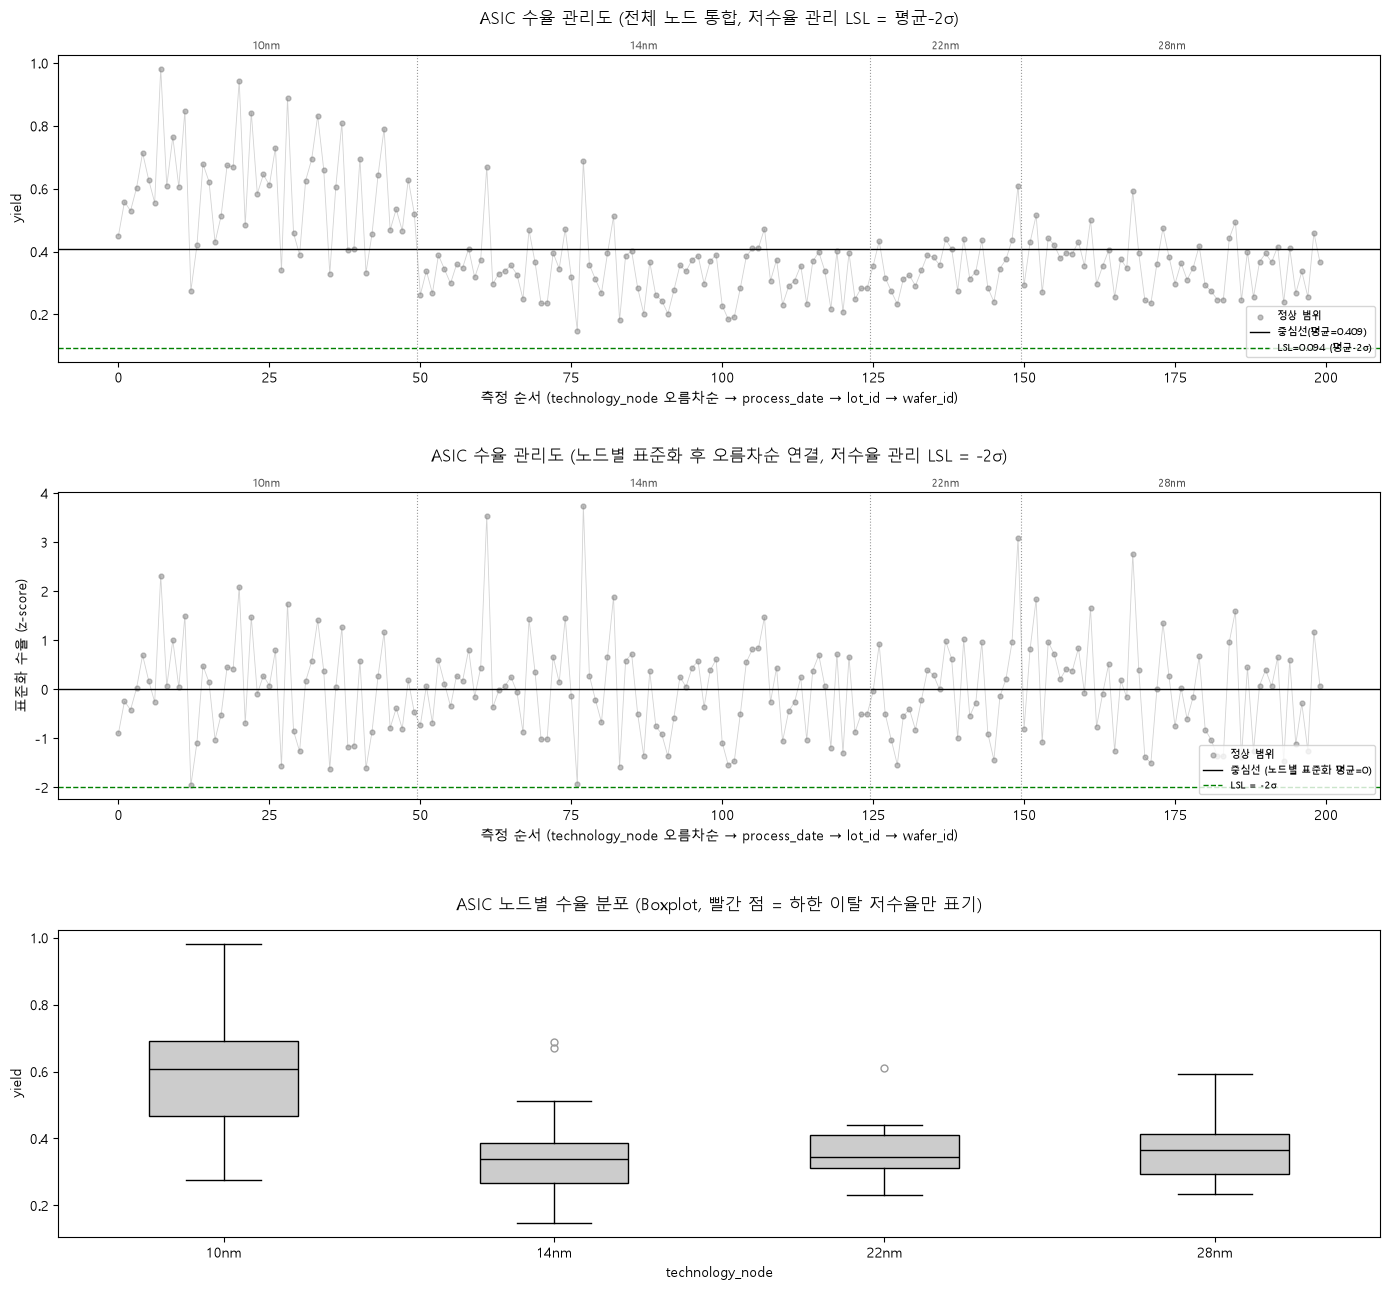

표준화 관리도 이상치 (z < -2)


,technology_node,lot_id,wafer_id


Boxplot 이상치 (IQR 범위 이탈)


,technology_node,lot_id,wafer_id


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_pooled_chart(axes[0], 'ASIC')
std_outliers = plot_standardized_chart(axes[1], 'ASIC')
box_outliers = plot_boxplot_with_outliers(axes[2], 'ASIC')
plt.tight_layout(h_pad=3.0)
plt.show()

print('표준화 관리도 이상치 (z < -2)')
display(std_outliers)

print('Boxplot 이상치 (IQR 범위 이탈)')
display(box_outliers)


#### 2) CPU

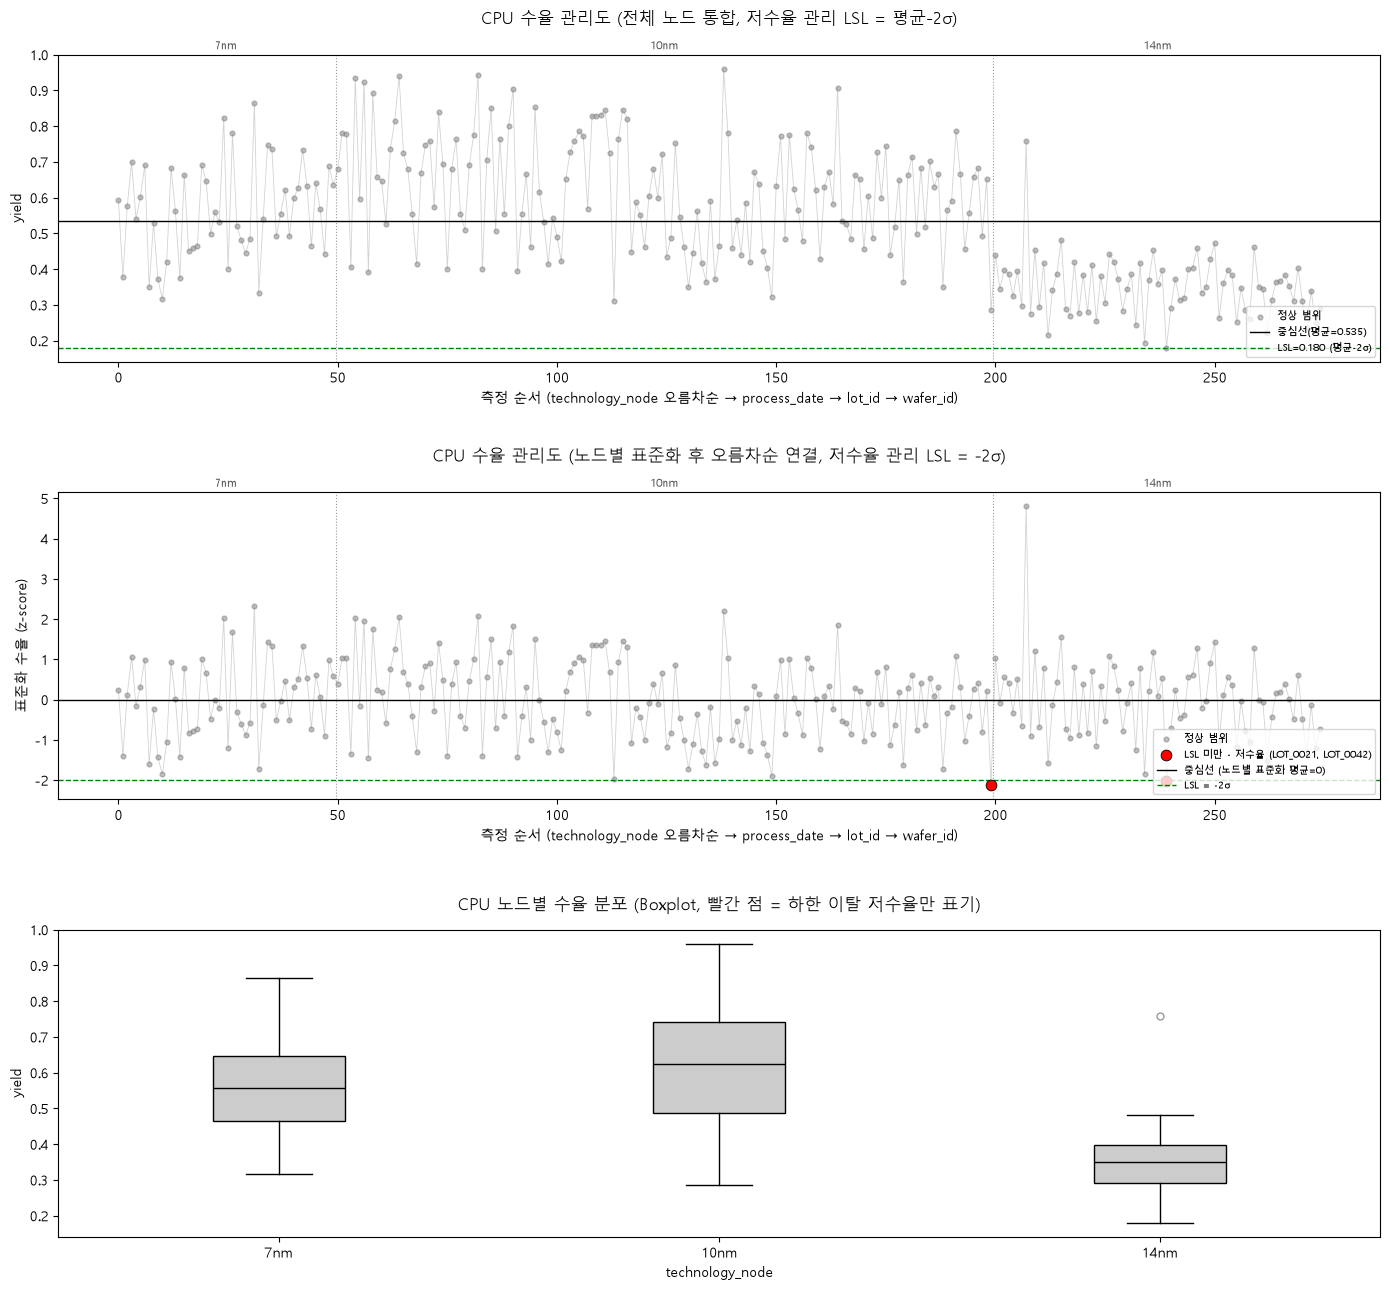

표준화 관리도 이상치 (z < -2)


,technology_node,lot_id,wafer_id
0,10nm,LOT_0042,W025
1,14nm,LOT_0021,W015


Boxplot 이상치 (IQR 범위 이탈)


,technology_node,lot_id,wafer_id


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_pooled_chart(axes[0], 'CPU')
std_outliers = plot_standardized_chart(axes[1], 'CPU')
box_outliers = plot_boxplot_with_outliers(axes[2], 'CPU')
plt.tight_layout(h_pad=3.0)
plt.show()

print('표준화 관리도 이상치 (z < -2)')
display(std_outliers)

print('Boxplot 이상치 (IQR 범위 이탈)')
display(box_outliers)


#### 3) FPGA

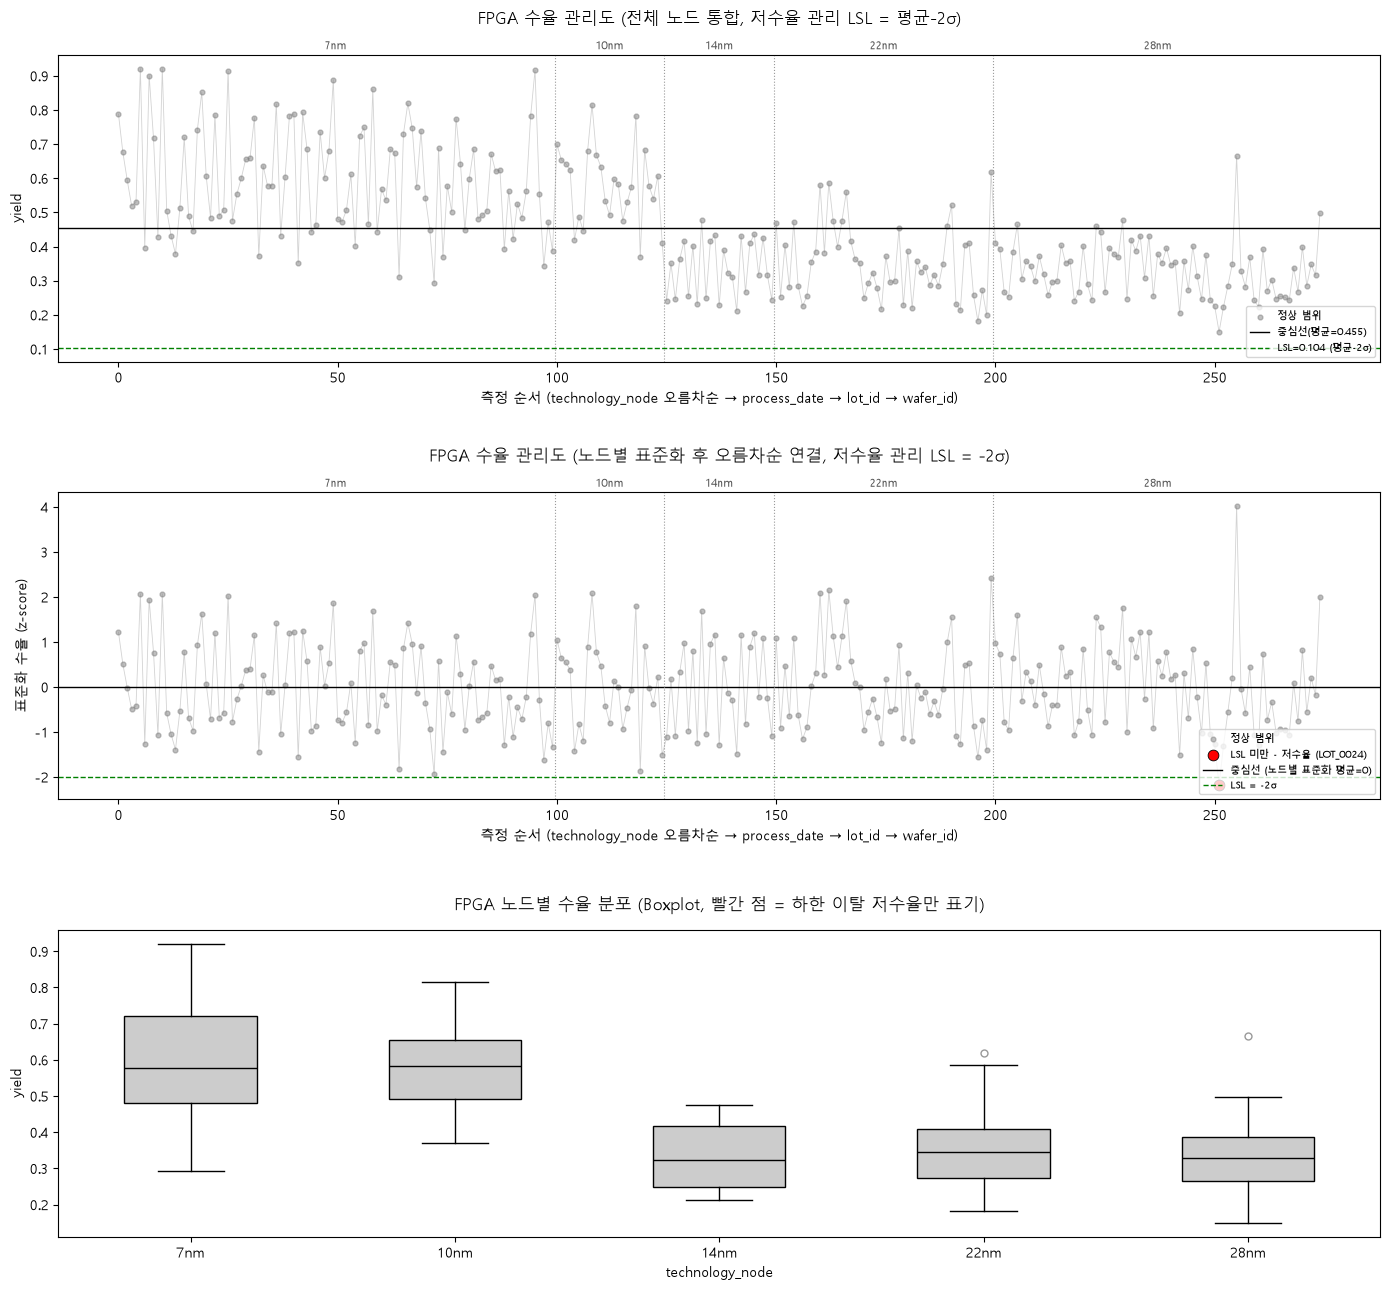

표준화 관리도 이상치 (z < -2)


,technology_node,lot_id,wafer_id
0,28nm,LOT_0024,W002


Boxplot 이상치 (IQR 범위 이탈)


,technology_node,lot_id,wafer_id


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_pooled_chart(axes[0], 'FPGA')
std_outliers = plot_standardized_chart(axes[1], 'FPGA')
box_outliers = plot_boxplot_with_outliers(axes[2], 'FPGA')
plt.tight_layout(h_pad=3.0)
plt.show()

print('표준화 관리도 이상치 (z < -2)')
display(std_outliers)

print('Boxplot 이상치 (IQR 범위 이탈)')
display(box_outliers)


#### 4) GPU

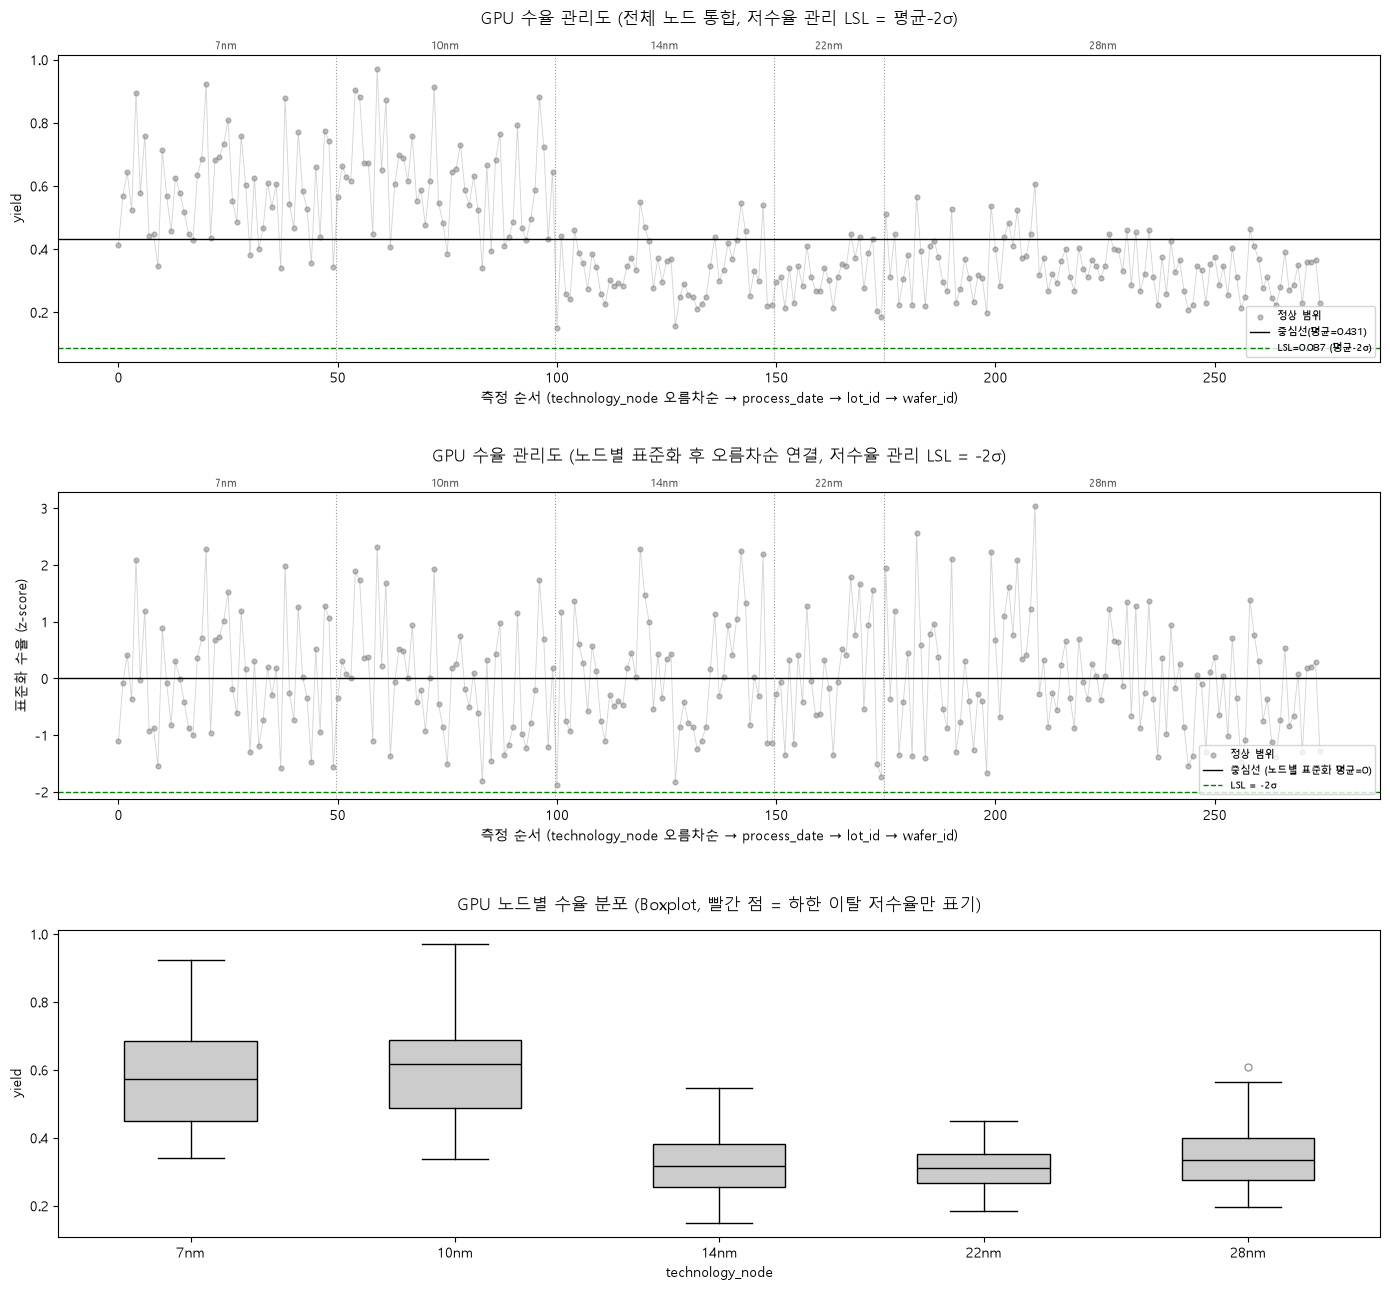

표준화 관리도 이상치 (z < -2)


,technology_node,lot_id,wafer_id


Boxplot 이상치 (IQR 범위 이탈)


,technology_node,lot_id,wafer_id


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_pooled_chart(axes[0], 'GPU')
std_outliers = plot_standardized_chart(axes[1], 'GPU')
box_outliers = plot_boxplot_with_outliers(axes[2], 'GPU')
plt.tight_layout(h_pad=3.0)
plt.show()

print('표준화 관리도 이상치 (z < -2)')
display(std_outliers)

print('Boxplot 이상치 (IQR 범위 이탈)')
display(box_outliers)


#### 5) MEMORY

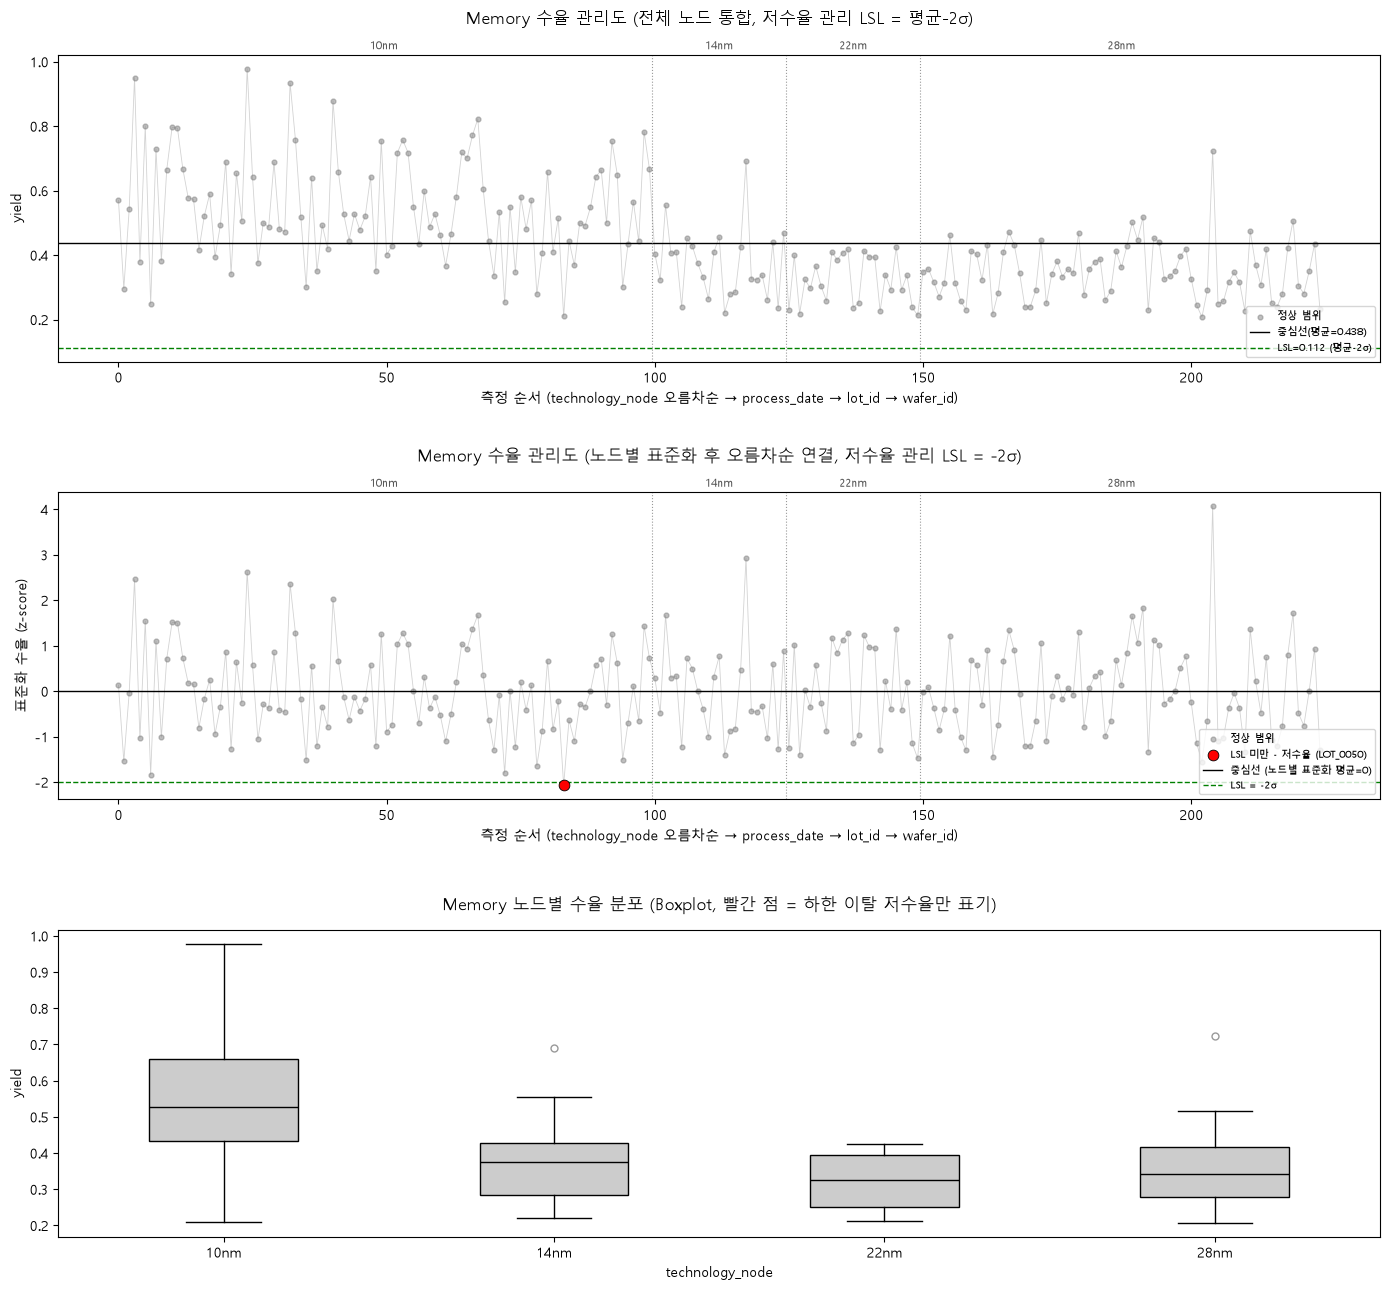

표준화 관리도 이상치 (z < -2)


,technology_node,lot_id,wafer_id
0,10nm,LOT_0050,W009


Boxplot 이상치 (IQR 범위 이탈)


,technology_node,lot_id,wafer_id


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_pooled_chart(axes[0], 'Memory')
std_outliers = plot_standardized_chart(axes[1], 'Memory')
box_outliers = plot_boxplot_with_outliers(axes[2], 'Memory')
plt.tight_layout(h_pad=3.0)
plt.show()

print('표준화 관리도 이상치 (z < -2)')
display(std_outliers)

print('Boxplot 이상치 (IQR 범위 이탈)')
display(box_outliers)


저장소에 올린 날 : [2026-08-24]